In [1]:
# --- 1. Imports and Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ✅ FIXED keras imports using TensorFlow's Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences

import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# --- 2. Load and Prepare Data ---
fake_df = pd.read_csv('Fake.csv')
true_df = pd.read_csv('True.csv')

# Add labels
fake_df['label'] = 1
true_df['label'] = 0

# Combine and shuffle
df = pd.concat([fake_df, true_df], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Use 'title' for now (you can switch to 'text' if preferred)
df = df[['title', 'label']].dropna()
df['title'] = df['title'].astype(str)


In [3]:
# --- 3. Text Preprocessing ---
stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer("english")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\[.*?\]", "", text)
    text = re.sub(r"[%s]" % re.escape(string.punctuation), " ", text)
    text = re.sub(r"\w*\d\w*", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['clean_text'] = df['title'].apply(clean_text)


In [4]:
# --- 4. Tokenization and Padding ---
voc_size = 5000
max_len = 20

df['encoded'] = df['clean_text'].apply(lambda x: one_hot(x, voc_size))
X = pad_sequences(df['encoded'], maxlen=max_len, padding='post')
y = pd.get_dummies(df['label']).values


In [5]:
# --- 5. Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
# --- 6. Model Definition ---
model = Sequential()
model.add(Embedding(voc_size, 40, input_length=max_len))
model.add(LSTM(100))
model.add(Dense(2, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 20, 40)            200000    
                                                                 
 lstm (LSTM)                 (None, 100)               56400     
                                                                 
 dense (Dense)               (None, 2)                 202       
                                                                 
Total params: 256,602
Trainable params: 256,602
Non-trainable params: 0
_________________________________________________________________


In [7]:
# --- 7. Model Training ---
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=64)


Epoch 1/5
562/562 [==============================] - 15s 23ms/step - loss: 0.2224 - accuracy: 0.9061 - val_loss: 0.1686 - val_accuracy: 0.9339
Epoch 2/5
562/562 [==============================] - 11s 20ms/step - loss: 0.1488 - accuracy: 0.9422 - val_loss: 0.1618 - val_accuracy: 0.9379
Epoch 3/5
562/562 [==============================] - 12s 21ms/step - loss: 0.1300 - accuracy: 0.9507 - val_loss: 0.1723 - val_accuracy: 0.9367
Epoch 4/5
562/562 [==============================] - 12s 21ms/step - loss: 0.1174 - accuracy: 0.9556 - val_loss: 0.1787 - val_accuracy: 0.9355
Epoch 5/5
562/562 [==============================] - 12s 21ms/step - loss: 0.1046 - accuracy: 0.9609 - val_loss: 0.1494 - val_accuracy: 0.9419


In [8]:
# --- 8. Evaluation ---
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

print(classification_report(y_test_labels, y_pred_labels))
print(confusion_matrix(y_test_labels, y_pred_labels))
print("Accuracy:", accuracy_score(y_test_labels, y_pred_labels))


281/281 [==============================] - 2s 5ms/step
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      4270
           1       0.96      0.93      0.94      4710

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980

[[4077  193]
 [ 329 4381]]
Accuracy: 0.9418708240534521


In [9]:
# --- 9. Prediction Function ---
def predict_news(news_text):
    cleaned = clean_text(news_text)
    encoded = one_hot(cleaned, voc_size)
    padded = pad_sequences([encoded], maxlen=max_len, padding='post')
    prediction = model.predict(padded)
    label = np.argmax(prediction, axis=1)[0]
    return "FAKE" if label == 1 else "REAL"

# Example
print(predict_news("NASA confirms water on Mars for the first time"))

print(predict_news("FBI Russia probe helped by Australian diplomat tip-off: NYT"))



1/1 [==============================] - 0s 23ms/step
REAL
1/1 [==============================] - 0s 17ms/step
REAL


In [10]:
# Use X_train, X_test, y_train, y_test from earlier preprocessing.
input_dim = X_train.shape[1]
output_dim = y_train.shape[1]


In [11]:
model.save('news_model.h5')  # Save your model after training

In [12]:
import matplotlib.pyplot as plt

def plot_accuracy(history, model_name):
    plt.figure(figsize=(6, 4))
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.title(f'{model_name} Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

def plot_loss(history, model_name):
    plt.figure(figsize=(6, 4))
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(f'{model_name} Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


**CNN MODEL**

Epoch 1/10
562/562 [==============================] - 5s 9ms/step - loss: 0.2534 - accuracy: 0.8963 - val_loss: 0.1821 - val_accuracy: 0.9345
Epoch 2/10
562/562 [==============================] - 4s 8ms/step - loss: 0.1257 - accuracy: 0.9523 - val_loss: 0.1791 - val_accuracy: 0.9320
Epoch 3/10
562/562 [==============================] - 5s 9ms/step - loss: 0.0810 - accuracy: 0.9712 - val_loss: 0.1827 - val_accuracy: 0.9343
Epoch 4/10
562/562 [==============================] - 5s 8ms/step - loss: 0.0491 - accuracy: 0.9837 - val_loss: 0.2129 - val_accuracy: 0.9300
Epoch 5/10
562/562 [==============================] - 5s 9ms/step - loss: 0.0291 - accuracy: 0.9910 - val_loss: 0.2388 - val_accuracy: 0.9276
Epoch 6/10
562/562 [==============================] - 5s 8ms/step - loss: 0.0166 - accuracy: 0.9951 - val_loss: 0.2845 - val_accuracy: 0.9257
Epoch 7/10
562/562 [==============================] - 5s 8ms/step - loss: 0.0095 - accuracy: 0.9972 - val_loss: 0.3316 - val_accuracy: 0.9223
Epoch 

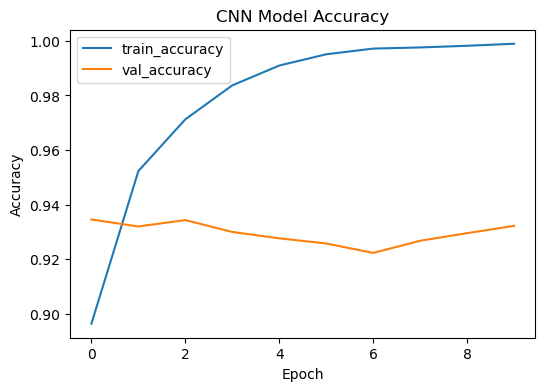

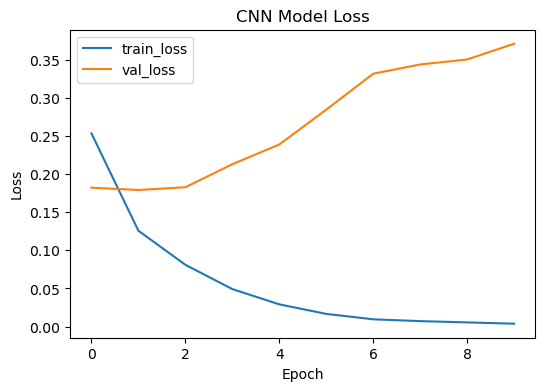

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dropout, Dense


def create_cnn_model():
    model = Sequential()
    model.add(Embedding(voc_size, 40, input_length=max_len))
    model.add(Conv1D(128, 5, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(2, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

cnn_model = create_cnn_model()
cnn_history = cnn_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=64)
plot_accuracy(cnn_history, "CNN")
plot_loss(cnn_history, "CNN")


**Bidirectional LSTM MODEL**

Epoch 1/10
562/562 [==============================] - 26s 41ms/step - loss: 0.2155 - accuracy: 0.9109 - val_loss: 0.1521 - val_accuracy: 0.9379
Epoch 2/10
562/562 [==============================] - 20s 36ms/step - loss: 0.1273 - accuracy: 0.9512 - val_loss: 0.1488 - val_accuracy: 0.9420
Epoch 3/10
562/562 [==============================] - 20s 35ms/step - loss: 0.0969 - accuracy: 0.9632 - val_loss: 0.1397 - val_accuracy: 0.9461
Epoch 4/10
562/562 [==============================] - 20s 35ms/step - loss: 0.0780 - accuracy: 0.9706 - val_loss: 0.1502 - val_accuracy: 0.9430
Epoch 5/10
562/562 [==============================] - 20s 35ms/step - loss: 0.0612 - accuracy: 0.9780 - val_loss: 0.1702 - val_accuracy: 0.9420
Epoch 6/10
562/562 [==============================] - 20s 36ms/step - loss: 0.0490 - accuracy: 0.9832 - val_loss: 0.1831 - val_accuracy: 0.9412
Epoch 7/10
562/562 [==============================] - 20s 35ms/step - loss: 0.0387 - accuracy: 0.9857 - val_loss: 0.2009 - val_accuracy:

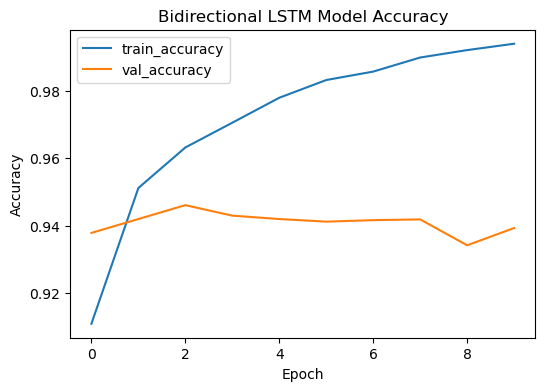

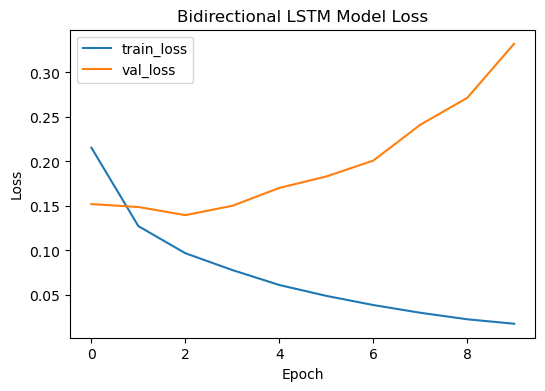

In [14]:
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense
from tensorflow.keras.models import Sequential


def create_bilstm_model():
    model = Sequential()
    model.add(Embedding(voc_size, 40, input_length=max_len))
    model.add(Bidirectional(LSTM(100)))
    model.add(Dense(2, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

bilstm_model = create_bilstm_model()
bilstm_history = bilstm_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=64)
plot_accuracy(bilstm_history, "Bidirectional LSTM")
plot_loss(bilstm_history, "Bidirectional LSTM")


**ResNet-style MODEL**

Epoch 1/10
562/562 [==============================] - 8s 12ms/step - loss: 0.2604 - accuracy: 0.8886 - val_loss: 0.1641 - val_accuracy: 0.9350
Epoch 2/10
562/562 [==============================] - 5s 9ms/step - loss: 0.1221 - accuracy: 0.9533 - val_loss: 0.1542 - val_accuracy: 0.9431
Epoch 3/10
562/562 [==============================] - 5s 9ms/step - loss: 0.0737 - accuracy: 0.9744 - val_loss: 0.1595 - val_accuracy: 0.9429
Epoch 4/10
562/562 [==============================] - 5s 9ms/step - loss: 0.0397 - accuracy: 0.9876 - val_loss: 0.2014 - val_accuracy: 0.9399
Epoch 5/10
562/562 [==============================] - 5s 9ms/step - loss: 0.0195 - accuracy: 0.9937 - val_loss: 0.2473 - val_accuracy: 0.9392
Epoch 6/10
562/562 [==============================] - 5s 9ms/step - loss: 0.0085 - accuracy: 0.9977 - val_loss: 0.2990 - val_accuracy: 0.9403
Epoch 7/10
562/562 [==============================] - 5s 9ms/step - loss: 0.0042 - accuracy: 0.9989 - val_loss: 0.3564 - val_accuracy: 0.9363
Epoch

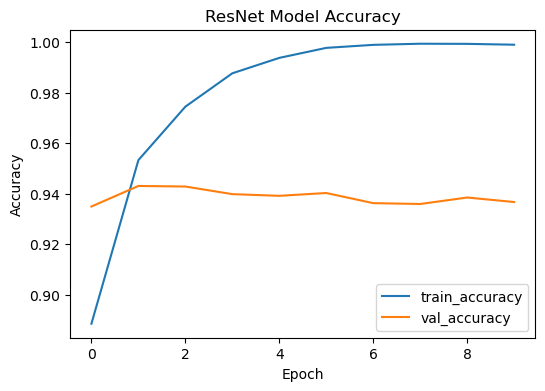

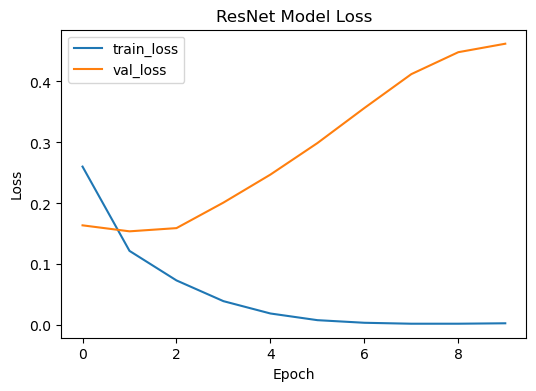

In [15]:
from keras.layers import Input, Add, Activation
from keras.models import Model

def create_resnet_model():
    input_layer = Input(shape=(max_len,))
    x = Embedding(voc_size, 40)(input_layer)
    x1 = Conv1D(64, 3, padding='same', activation='relu')(x)
    x2 = Conv1D(64, 3, padding='same')(x1)
    x_res = Add()([x1, x2])
    x_res = Activation('relu')(x_res)
    x_res = GlobalMaxPooling1D()(x_res)
    output = Dense(2, activation='softmax')(x_res)
    model = Model(inputs=input_layer, outputs=output)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

resnet_model = create_resnet_model()
resnet_history = resnet_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=64)
plot_accuracy(resnet_history, "ResNet")
plot_loss(resnet_history, "ResNet")


**CoBRA (BiLSTM + Attention Approx.)**

Epoch 1/10
562/562 [==============================] - 17s 26ms/step - loss: 0.2086 - accuracy: 0.9121 - val_loss: 0.1430 - val_accuracy: 0.9419
Epoch 2/10
562/562 [==============================] - 14s 25ms/step - loss: 0.1246 - accuracy: 0.9515 - val_loss: 0.1409 - val_accuracy: 0.9455
Epoch 3/10
562/562 [==============================] - 14s 26ms/step - loss: 0.0977 - accuracy: 0.9628 - val_loss: 0.1556 - val_accuracy: 0.9389
Epoch 4/10
562/562 [==============================] - 14s 25ms/step - loss: 0.0785 - accuracy: 0.9693 - val_loss: 0.1640 - val_accuracy: 0.9442
Epoch 5/10
562/562 [==============================] - 14s 25ms/step - loss: 0.0646 - accuracy: 0.9757 - val_loss: 0.1908 - val_accuracy: 0.9385
Epoch 6/10
562/562 [==============================] - 14s 26ms/step - loss: 0.0501 - accuracy: 0.9813 - val_loss: 0.2215 - val_accuracy: 0.9380
Epoch 7/10
562/562 [==============================] - 15s 27ms/step - loss: 0.0395 - accuracy: 0.9859 - val_loss: 0.2501 - val_accuracy:

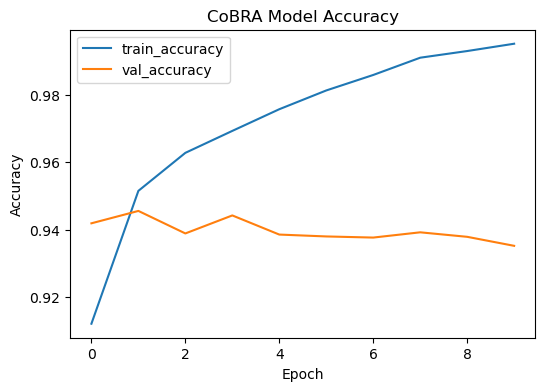

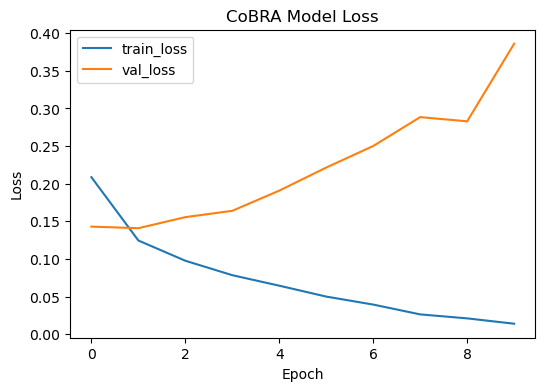

In [16]:
from keras.models import Model
from keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dot, Activation, Permute, Multiply, Lambda, GlobalAveragePooling1D
import tensorflow.keras.backend as K

def attention_layer(inputs):
    # Attention mechanism
    attention_scores = Dense(1, activation='tanh')(inputs)
    attention_weights = Activation('softmax')(attention_scores)
    context_vector = Multiply()([inputs, attention_weights])
    context_vector = Lambda(lambda x: K.sum(x, axis=1))(context_vector)
    return context_vector

def create_cobra_model():
    input_layer = Input(shape=(max_len,))
    x = Embedding(voc_size, 40, input_length=max_len)(input_layer)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = attention_layer(x)
    output = Dense(2, activation='softmax')(x)
    model = Model(inputs=input_layer, outputs=output)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

cobra_model = create_cobra_model()
cobra_history = cobra_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=64)
plot_accuracy(cobra_history, "CoBRA")
plot_loss(cobra_history, "CoBRA")
